In [1]:
import pandas as pd

df = pd.read_csv('aice_multiclass_onehot_practice.csv')

df.head()

,customer_id,signup_date,age,monthly_spend,visits_per_month,support_calls,membership_type,region,device,satisfaction_score,target_segment
0,OH0273,2021-04-05,28.0,97.30,13,1,Silver,Daejeon,Web,3.6,Gold
1,OH0435,2024-01-17,40.0,98.37,9,2,VIP,Daegu,Android,4.9,Platinum
2,OH0120,2023-09-27,42.0,170.92,7,2,Silver,Seoul,Web,2.9,Silver
3,OH0420,2021-03-25,52.0,226.54,13,3,VIP,Busan,iOS,2.8,Platinum
4,OH0155,2021-12-25,18.0,111.23,14,3,Gold,Daejeon,iOS,4.7,Platinum


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 632 entries, 0 to 631
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         632 non-null    str    
 1   signup_date         632 non-null    str    
 2   age                 612 non-null    float64
 3   monthly_spend       616 non-null    float64
 4   visits_per_month    632 non-null    int64  
 5   support_calls       632 non-null    int64  
 6   membership_type     614 non-null    str    
 7   region              632 non-null    str    
 8   device              632 non-null    str    
 9   satisfaction_score  632 non-null    float64
 10  target_segment      632 non-null    str    
dtypes: float64(3), int64(2), str(6)
memory usage: 54.4 KB


In [3]:
df.isnull().sum()

customer_id            0
signup_date            0
age                   20
monthly_spend         16
visits_per_month       0
support_calls          0
membership_type       18
region                 0
device                 0
satisfaction_score     0
target_segment         0
dtype: int64

In [4]:
df.describe()

,age,monthly_spend,visits_per_month,support_calls,satisfaction_score
count,612.000000,616.000000,632.000000,632.000000,632.000000
mean,40.624183,158.079237,11.814873,2.090190,3.482595
std,12.888770,157.164803,8.026436,1.623841,0.793424
min,18.000000,10.000000,1.000000,0.000000,1.200000
25%,32.750000,106.910000,8.000000,1.000000,2.900000
50%,40.000000,146.615000,11.000000,2.000000,3.500000
75%,48.000000,185.152500,15.000000,3.000000,4.100000
max,115.000000,2500.000000,90.000000,8.000000,5.000000


In [ ]:
# 중복행 제거

df[df.duplicated()]

# 중복행 개수
df.duplicated().sum()

df_original = df.copy()

df = df.drop_duplicates()

In [6]:
# 인덱스 기준 재정렬 / drop=True -> 인덱스를 새 컬럼으로 남기지 말고 버려라
df = df.reset_index(drop=True)

In [7]:
# 결측치 처리
df['age'] = df['age'].fillna(df['age'].median())
df['monthly_spend'] = df['monthly_spend'].fillna(df['monthly_spend'].median())
df['membership_type'] = df['membership_type'].fillna(df['membership_type'].mode()[0])

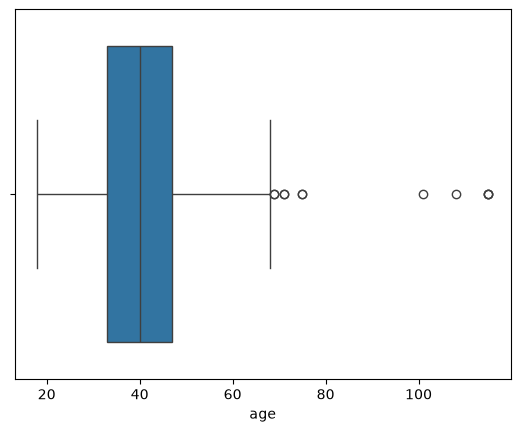

In [8]:
# 이상치 확인
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x='age')
plt.show()

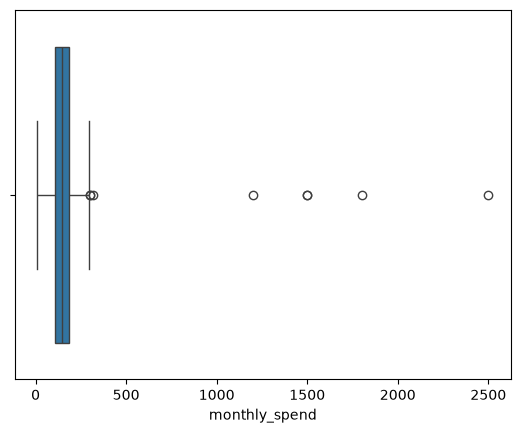

In [9]:
sns.boxplot(data=df, x='monthly_spend')
plt.show()

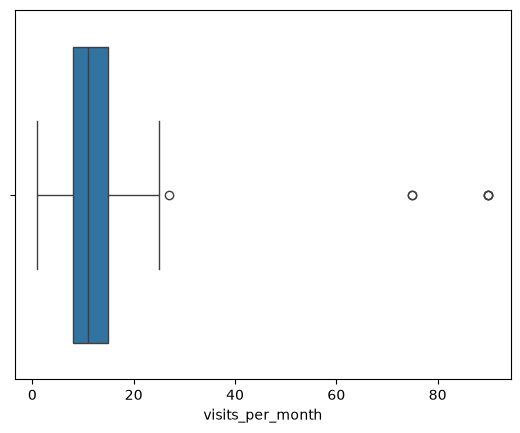

In [10]:
sns.boxplot(data=df, x='visits_per_month')
plt.show()

In [11]:
# 이상치 처리
df = df[(df['age']<=100) & (df['monthly_spend']<= 1000) & (df['visits_per_month'] <= 60)]

df.info()

<class 'pandas.DataFrame'>
Index: 605 entries, 0 to 617
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         605 non-null    str    
 1   signup_date         605 non-null    str    
 2   age                 605 non-null    float64
 3   monthly_spend       605 non-null    float64
 4   visits_per_month    605 non-null    int64  
 5   support_calls       605 non-null    int64  
 6   membership_type     605 non-null    str    
 7   region              605 non-null    str    
 8   device              605 non-null    str    
 9   satisfaction_score  605 non-null    float64
 10  target_segment      605 non-null    str    
dtypes: float64(3), int64(2), str(6)
memory usage: 56.7 KB


In [12]:
# 날짜 변환 및 컬럼 생성 / 제거
df['signup_date'] = pd.to_datetime(df['signup_date'])

df['signup_year'] = df['signup_date'].dt.year
df['signup_month'] = df['signup_date'].dt.month

df = df.drop(columns=['signup_date'])

In [13]:
print(df['membership_type'].value_counts())
print(df['region'].value_counts())
print(df['device'].value_counts())

membership_type
Basic     194
Silver    172
Gold      157
VIP        82
Name: count, dtype: int64
region
Daegu      140
Incheon    134
Daejeon    112
Busan      112
Seoul      107
Name: count, dtype: int64
device
Android    277
iOS        216
Web        112
Name: count, dtype: int64


In [14]:
# one hot encoding
df = pd.get_dummies(df, columns=['membership_type', 'region', 'device'], dtype=int)

df.head()

,customer_id,age,monthly_spend,visits_per_month,support_calls,satisfaction_score,target_segment,signup_year,signup_month,membership_type_Basic,...,membership_type_Silver,membership_type_VIP,region_Busan,region_Daegu,region_Daejeon,region_Incheon,region_Seoul,device_Android,device_Web,device_iOS
0,OH0273,28.0,97.30,13,1,3.6,Gold,2021,4,0,...,1,0,0,0,1,0,0,0,1,0
1,OH0435,40.0,98.37,9,2,4.9,Platinum,2024,1,0,...,0,1,0,1,0,0,0,1,0,0
2,OH0120,42.0,170.92,7,2,2.9,Silver,2023,9,0,...,1,0,0,0,0,0,1,0,1,0
3,OH0420,52.0,226.54,13,3,2.8,Platinum,2021,3,0,...,0,1,1,0,0,0,0,0,0,1
4,OH0155,18.0,111.23,14,3,4.7,Platinum,2021,12,0,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
# x / y 분리
x = df.drop(columns=['customer_id', 'target_segment'])
y = df['target_segment']

# 해당 범주형은 분리 후 one hot
y = pd.get_dummies(y, columns=['target_segment'])

y.shape

(605, 4)

In [ ]:
# x, y 분리 - stratify에 대한 설명이 없어서 생략
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, Input
import numpy as np

# one-hot 에서는 해당 방법 사용
num_classes = y_train.shape[1]

model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [21]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [23]:
# 모델 학습
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2119 - loss: 1.5027 - val_accuracy: 0.2680 - val_loss: 1.3808
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3152 - loss: 1.3713 - val_accuracy: 0.3608 - val_loss: 1.2945
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3876 - loss: 1.2908 - val_accuracy: 0.4845 - val_loss: 1.2278
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4548 - loss: 1.2269 - val_accuracy: 0.4948 - val_loss: 1.1690
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5090 - loss: 1.1792 - val_accuracy: 0.5155 - val_loss: 1.1156
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5116 - loss: 1.1174 - val_accuracy: 0.5361 - val_loss: 1.0640
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5375 - loss: 1.0837 - val_accuracy: 0.5258 - val_loss: 1.0139
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5504 - loss: 1.0312 - val_accuracy: 0.5876 - val_loss

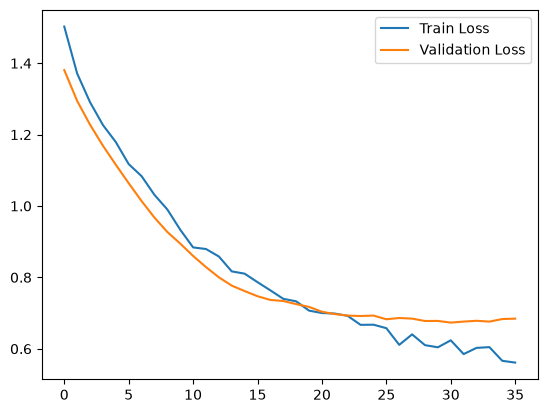

In [29]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.show()

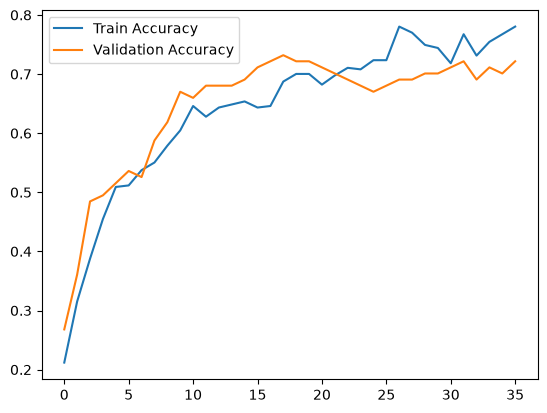

In [30]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()

In [31]:
test_loss, test_accuracy = model.evaluate(
    x_test_scaled,
    y_test
)

print(test_loss)
print(test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5702 - loss: 0.8898 
0.8898250460624695
0.5702479481697083
